## Francisco Tinoco

* Clase 26 -03

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

In [2]:
import kagglehub
path = kagglehub.dataset_download("shantanugarg274/heart-prediction-dataset-quantum")
print("Path to dataset files:", path)

c:\Users\Francisco\anaconda3\envs\nuevo\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Francisco\.cache\kagglehub\datasets\shantanugarg274\heart-prediction-dataset-quantum\versions\1


In [3]:
df = pd.read_csv("C:\\Users\\Francisco\\Downloads\\8vo Semestre\\Lab estadistico\\Lab-Aprendizaje-Estadistico\\Acts\\Act05\\Heart Prediction Quantum Dataset.csv")
df

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
0,68,1,105,191,107,8.362241,1
1,58,0,97,249,89,9.249002,0
2,44,0,93,190,82,7.942542,1
3,72,1,93,183,101,6.495155,1
4,37,0,145,166,103,7.653900,1
...,...,...,...,...,...,...,...
495,34,0,126,292,116,9.303403,0
496,41,0,164,248,114,9.067889,0
497,45,1,159,175,75,8.718708,0
498,55,0,107,157,101,7.337650,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    500 non-null    int64  
 1   Gender                 500 non-null    int64  
 2   BloodPressure          500 non-null    int64  
 3   Cholesterol            500 non-null    int64  
 4   HeartRate              500 non-null    int64  
 5   QuantumPatternFeature  500 non-null    float64
 6   HeartDisease           500 non-null    int64  
dtypes: float64(1), int64(6)
memory usage: 27.5 KB


#### Histogramas para ver las distribuciones y si alguna variable está sesgada :

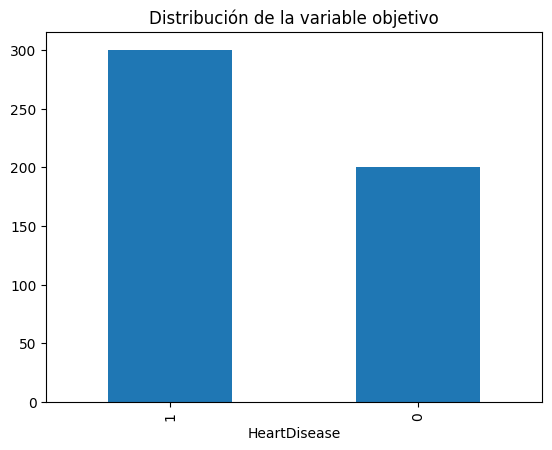

In [5]:
import matplotlib.pyplot as plt

df['HeartDisease'].value_counts().plot(kind='bar')
plt.title('Distribución de la variable objetivo')
plt.show()

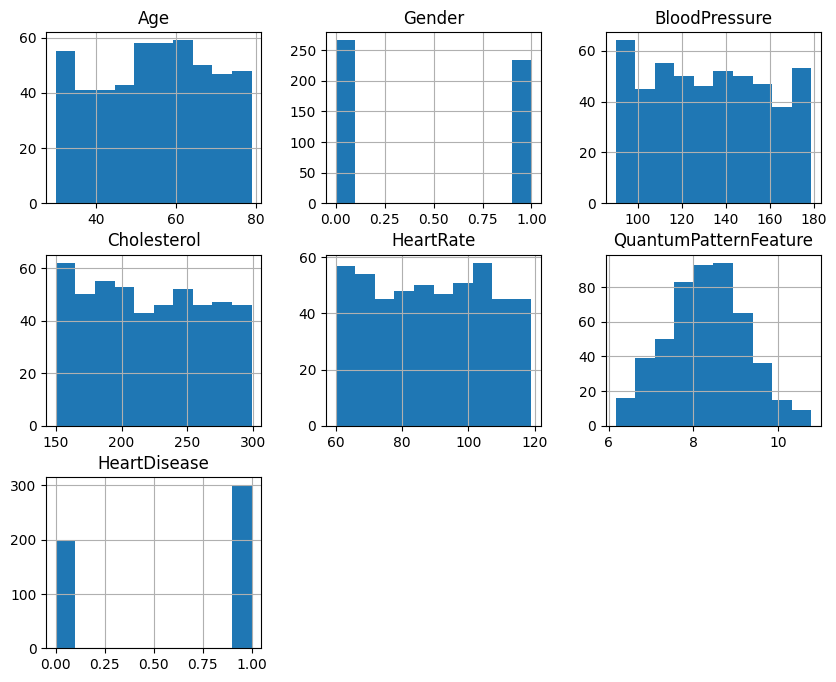

In [6]:
!pip install seaborn
import seaborn as sns

df.hist(figsize=(10,8))
plt.show()

In [7]:
df.describe()

,Age,Gender,BloodPressure,Cholesterol,HeartRate,QuantumPatternFeature,HeartDisease
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000
mean,54.864000,0.468000,132.874000,221.50000,88.766000,8.317407,0.600000
std,14.315004,0.499475,26.418516,43.86363,17.417289,0.919629,0.490389
min,30.000000,0.000000,90.000000,150.00000,60.000000,6.164692,0.000000
25%,43.000000,0.000000,111.000000,183.75000,73.000000,7.675779,0.000000
50%,55.000000,0.000000,132.000000,221.00000,89.000000,8.323064,1.000000
75%,66.250000,1.000000,155.000000,258.00000,104.000000,8.935999,1.000000
max,79.000000,1.000000,179.000000,299.00000,119.000000,10.784886,1.000000


- No hay valores nulos en el dataset
- Las variables son completamente numéricas
- La variable objetivo está relativamente balanceada
- Algunas variables muestran correlación moderada con HeartDisease
- No se observan outliers extremos que requieran limpieza inmediata

### Dividimos en X, y ; 

* Empezamos definiendo nuestro modelo MLP para clasificar 'HeartDisease'

In [8]:
from sklearn.neural_network import MLPClassifier

In [9]:
from sklearn.model_selection import train_test_split

X = df.drop(['HeartDisease', 'QuantumPatternFeature'], axis=1)
y = df['HeartDisease']

In [12]:
X

,Age,Gender,BloodPressure,Cholesterol,HeartRate
0,68,1,105,191,107
1,58,0,97,249,89
2,44,0,93,190,82
3,72,1,93,183,101
4,37,0,145,166,103
...,...,...,...,...,...
495,34,0,126,292,116
496,41,0,164,248,114
497,45,1,159,175,75
498,55,0,107,157,101


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [15]:
mlp = MLPClassifier(
    hidden_layer_sizes=(5,10),
    random_state=42
)

mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(5, 10), random_state=42)

In [16]:
y_pred = mlp.predict(X_test)

In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nReporte de clasificación:\n", classification_report(y_test, y_pred))

Accuracy: 0.8

Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.86      0.60      0.71        40
           1       0.78      0.93      0.85        60

    accuracy                           0.80       100
   macro avg       0.82      0.77      0.78       100
weighted avg       0.81      0.80      0.79       100



El parámetro hidden_layer_sizes=(5,10) indica que la red neuronal tiene:

- 2 capas ocultas
- Primera capa: 5 neuronas
- Segunda capa: 10 neuronas

Esto permite que el modelo capture relaciones no lineales en los datos, aumentando su capacidad de aprendizaje comparado con modelos lineales.

### Curva ROC con K=10

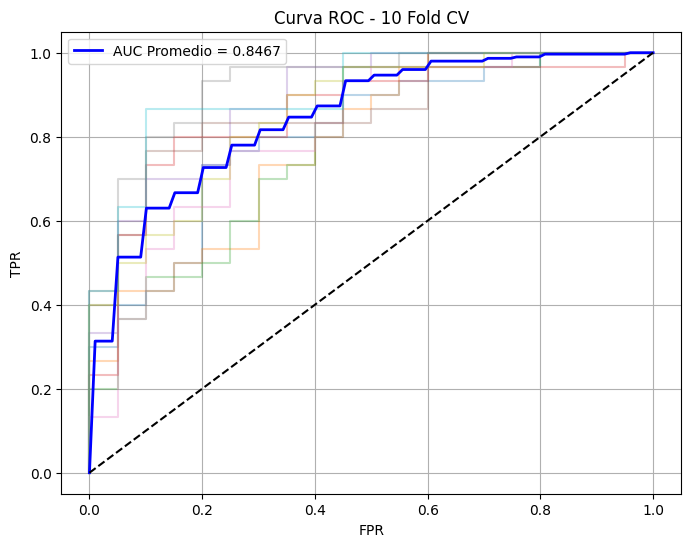

AUC promedio: 0.8467


In [27]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
mlp_roc = MLPClassifier(hidden_layer_sizes=(5,10), random_state=42, max_iter=500)

tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)

plt.figure(figsize=(8,6))

for fold, (train_idx, test_idx) in enumerate(cv.split(X_scaled, y)):
    X_tr, X_te = X_scaled[train_idx], X_scaled[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    
    mlp_roc.fit(X_tr, y_tr)
    y_prob = mlp_roc.predict_proba(X_te)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_te, y_prob)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)
    
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)
    
    plt.plot(fpr, tpr, alpha=0.3)

mean_tpr = np.mean(tprs, axis=0)
mean_auc = np.mean(aucs)
plt.plot(mean_fpr, mean_tpr, 'b-', lw=2, label=f'AUC Promedio = {mean_auc:.4f}')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC - 10 Fold CV')
plt.legend()
plt.grid()
plt.show()

print(f"AUC promedio: {mean_auc:.4f}")

### Optimizacion Bayesiana para 3 capas

Rangos: [2,6], [5,15], [3,16]

In [19]:
def evaluar_mlp(c1, c2, c3):
    mlp = MLPClassifier(hidden_layer_sizes=(int(c1), int(c2), int(c3)), random_state=42, max_iter=500)
    scores = cross_val_score(mlp, X_scaled, y, cv=10, scoring='roc_auc')
    return scores.mean()

In [20]:
from itertools import product

c1_vals = np.arange(2, 7)
c2_vals = np.arange(5, 16)
c3_vals = np.arange(3, 17)
todas = np.array(list(product(c1_vals, c2_vals, c3_vals)))

np.random.seed(42)
idx_inicial = np.random.choice(len(todas), 5, replace=False)
X_obs = todas[idx_inicial].astype(float)
y_obs = np.array([evaluar_mlp(*x) for x in X_obs])

print("Puntos iniciales:")
for x, y_val in zip(X_obs, y_obs):
    print(f"  ({int(x[0])}, {int(x[1])}, {int(x[2])}) -> AUC = {y_val:.4f}")

Puntos iniciales:
  (6, 8, 15) -> AUC = 0.8252
  (6, 14, 14) -> AUC = 0.8457
  (6, 12, 16) -> AUC = 0.8168
  (5, 13, 11) -> AUC = 0.8443
  (6, 13, 12) -> AUC = 0.8225


In [25]:
gpr = GaussianProcessRegressor(kernel=RBF(), random_state=42)

for i in range(20):
    gpr.fit(X_obs, y_obs)
    y_pred, y_std = gpr.predict(todas, return_std=True)
    
    ucb = y_pred + 2*y_std
    idx = np.argmax(ucb)
    x_new = todas[idx]
    y_new = evaluar_mlp(*x_new)
    
    X_obs = np.vstack([X_obs, x_new])
    y_obs = np.append(y_obs, y_new)
    
    print(f"Iter {i+1}: ({int(x_new[0])}, {int(x_new[1])}, {int(x_new[2])}) -> AUC = {y_new:.4f}")

Iter 1: (4, 15, 13) -> AUC = 0.8342
Iter 2: (5, 15, 6) -> AUC = 0.8294
Iter 3: (5, 8, 6) -> AUC = 0.8475
Iter 4: (2, 12, 13) -> AUC = 0.8137
Iter 5: (4, 15, 3) -> AUC = 0.8122
Iter 6: (2, 12, 6) -> AUC = 0.8157
Iter 7: (4, 7, 16) -> AUC = 0.8337
Iter 8: (6, 12, 4) -> AUC = 0.8352
Iter 9: (4, 5, 6) -> AUC = 0.8235
Iter 10: (4, 9, 11) -> AUC = 0.8286
Iter 11: (6, 5, 6) -> AUC = 0.8252
Iter 12: (6, 15, 11) -> AUC = 0.8403
Iter 13: (6, 5, 13) -> AUC = 0.8385
Iter 14: (6, 15, 16) -> AUC = 0.8308
Iter 15: (3, 13, 16) -> AUC = 0.8177
Iter 16: (5, 7, 3) -> AUC = 0.8366
Iter 17: (2, 7, 15) -> AUC = 0.7778
Iter 18: (4, 11, 8) -> AUC = 0.8172
Iter 19: (2, 10, 3) -> AUC = 0.8289
Iter 20: (2, 13, 3) -> AUC = 0.7891


In [26]:
# Mejor combinacion :

idx_mejor = np.argmax(y_obs)
mejor = X_obs[idx_mejor]
print(f"  hidden_layer_sizes = ({int(mejor[0])}, {int(mejor[1])}, {int(mejor[2])})")
print(f"  AUC = {y_obs[idx_mejor]:.4f}")

  hidden_layer_sizes = (5, 5, 9)
  AUC = 0.8500


Al usar 10 folds obtenemos una estimación más confiable del rendimiento real

### Conclusiones :

- La mejora es pequeña, lo que indica que el modelo original ya era bastante bueno
- La mejor configuración tiene menos neuronas en total (5+5+9=19) vs algunas probadas con más (ej: 4+15+13=32)
- Más neuronas no siempre significa mejor rendimiento
- La optimización bayesiana encontró el mejor resultado en los puntos iniciales, las 20 iteraciones adicionales no lo superaron